# Kalshi Prediction Markets: Regulated Event Contracts

**Chapter 4: Fundamental and Alternative Data**
**Docker image**: `ml4t`

## Purpose

Kalshi is the first CFTC-regulated prediction market in the US, offering binary
contracts on economic, market, and policy events. This notebook loads real Kalshi
OHLCV data and demonstrates how to build event probability indicators for ML
feature engineering and regime detection.

## Learning Objectives

After completing this notebook, you will be able to:
- Understand Kalshi contract structure and implied probability pricing
- Load and explore real OHLCV data from the Kalshi API
- Build event probability indicators for ML pipelines
- Assess prediction market data quality for systematic use

## Cross-References

- **Upstream**: `data/prediction_markets/download.py` (fetches data)
- **Downstream**: Chapter 8 event features, macro regime indicators
- **Related**: [`13_polymarket_prediction_markets`](13_polymarket_prediction_markets.ipynb) (crypto-based alternative)

In [1]:
"""Kalshi Prediction Markets — build event probability indicators from regulated binary contracts."""

import warnings

warnings.filterwarnings("ignore")

import plotly.graph_objects as go
import polars as pl
from plotly.subplots import make_subplots

from data.prediction_markets.loader import load_kalshi
from utils.paths import get_output_dir
from utils.style import COLORS

In [2]:
# Production defaults — Papermill injects overrides for CI

## 1. Kalshi Contract Structure

Kalshi contracts are binary event contracts that settle at \$0 or \$1.
The contract price represents the market's implied probability of the event.

| Feature | Description |
|---------|-------------|
| **Regulation** | CFTC-regulated (legal in US) |
| **Settlement** | USD (real dollars) |
| **Position Limit** | \$25,000 per contract |
| **Trading Hours** | 24/7 |
| **Min Tick** | \$0.01 |

### Ticker Format

`KXFED-27APR-T4.25` decodes as:
- **KXFED**: Federal Funds Rate series
- **27APR**: April 2027 FOMC meeting
- **T4.25**: threshold — contract pays \$1 if rate is **above** 4.25%

The `close` price is the implied probability (0–1) that the rate will
exceed the threshold at that meeting.

## 2. Load Kalshi Data

We load pre-downloaded OHLCV data from the Kalshi API. The download script
(`data/prediction_markets/download.py`) fetches all configured economic series
and stores them in canonical OHLCV format.

In [3]:
df = load_kalshi()

print(f"Loaded {len(df):,} observations across {df['symbol'].n_unique()} contracts")
print(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")

df.group_by("symbol").len().rename({"len": "days"}).sort("symbol")

Loaded 687 observations across 9 contracts
Date range: 2025-10-07 to 2025-12-31


symbol,days
str,u32
"""KXFED-27APR-T0.25""",73
"""KXFED-27APR-T2.25""",73
"""KXFED-27APR-T3.75""",73
"""KXFED-27APR-T4.00""",73
"""KXFED-27APR-T4.25""",67
"""KXFED-27JAN-T1.00""",86
"""KXFED-27JAN-T3.00""",86
"""KXFED-27MAR-T0.50""",78
"""KXFED-27MAR-T2.75""",78


In [4]:
df.head(10)

timestamp,symbol,open,high,low,close,volume,category
date,str,f64,f64,f64,f64,f64,str
2025-10-20,"""KXFED-27APR-T0.25""",0.43,0.93,0.0,0.93,0.0,"""monetary_policy"""
2025-10-21,"""KXFED-27APR-T0.25""",0.93,0.93,0.93,0.93,0.0,"""monetary_policy"""
2025-10-22,"""KXFED-27APR-T0.25""",0.93,0.93,0.93,0.93,0.0,"""monetary_policy"""
2025-10-23,"""KXFED-27APR-T0.25""",0.93,0.93,0.01,0.92,0.0,"""monetary_policy"""
2025-10-24,"""KXFED-27APR-T0.25""",0.92,0.92,0.92,0.92,0.0,"""monetary_policy"""
2025-10-25,"""KXFED-27APR-T0.25""",0.92,0.92,0.0,0.92,0.0,"""monetary_policy"""
2025-10-26,"""KXFED-27APR-T0.25""",0.92,0.92,0.92,0.92,0.0,"""monetary_policy"""
2025-10-27,"""KXFED-27APR-T0.25""",0.92,0.92,0.92,0.92,0.0,"""monetary_policy"""
2025-10-28,"""KXFED-27APR-T0.25""",0.92,0.92,0.92,0.92,0.0,"""monetary_policy"""


### Data Integrity Check

These KXFED contracts are thinly traded: only a handful of bars carry any volume, and
the rest are daily carry-forward snapshots. Two problems follow. First, some fields are
corrupt: a price of exactly 0 (open, low, or close) while the high still holds the prior
level is an ingestion artifact, since a live contract trades inside (0, 1) and never
prints a true zero the same day it closes near 0.9. Second, on a zero-volume day there
is no genuine intraday range at all, so a `low` far below the `close` is stale rather
than traded. The one reliable field is `close` (the implied probability). We therefore
carry the last valid close forward within each contract and rebuild every non-traded
bar as a flat snapshot at that close, keeping raw OHLC only where the bar actually
traded. Left unhandled, these artifacts inflate both the close-price range (misranking a
near-certain contract as "most active") and the intraday range shown in Section 6.

In [5]:
traded = pl.col("volume") > 0

# Report the clearest ingestion artifacts: a price field of exactly 0 with a positive high.
zero_price_mask = (pl.col("high") > 0.0) & (
    (pl.col("open") == 0.0) | (pl.col("low") == 0.0) | (pl.col("close") == 0.0)
)
artifact_bars = (
    df.filter(zero_price_mask)
    .select("timestamp", "symbol", "open", "high", "low", "close", "volume")
    .sort("timestamp", "symbol")
)
print(f"Zero-price artifact bars (a price field of 0 with a positive high): {artifact_bars.height}")
print(f"Genuinely traded bars (volume > 0): {df.filter(traded).height} of {df.height}")

# Repair: null any close that collapsed to 0, carry the last valid close forward (and
# backward for a leading gap) within each contract, then rebuild every non-traded bar as
# a flat snapshot at that close so no spurious intraday range survives.
df = (
    df.sort("symbol", "timestamp")
    .with_columns(
        pl.when((pl.col("close") == 0.0) & (pl.col("high") > 0.0))
        .then(None)
        .otherwise(pl.col("close"))
        .alias("close")
    )
    .with_columns(pl.col("close").forward_fill().over("symbol").alias("close"))
    .with_columns(pl.col("close").backward_fill().over("symbol").alias("close"))
    .with_columns(
        pl.when(traded).then(pl.col("open")).otherwise(pl.col("close")).alias("open"),
        pl.when(traded).then(pl.col("high")).otherwise(pl.col("close")).alias("high"),
        pl.when(traded).then(pl.col("low")).otherwise(pl.col("close")).alias("low"),
    )
)

artifact_bars

Zero-price artifact bars (a price field of 0 with a positive high): 35
Genuinely traded bars (volume > 0): 5 of 687


timestamp,symbol,open,high,low,close,volume
date,str,f64,f64,f64,f64,f64
2025-10-08,"""KXFED-27JAN-T1.00""",0.89,0.96,0.0,0.96,0.0
2025-10-08,"""KXFED-27JAN-T3.00""",0.61,0.61,0.0,0.51,0.0
2025-10-15,"""KXFED-27JAN-T1.00""",0.96,0.96,0.0,0.0,0.0
2025-10-15,"""KXFED-27JAN-T3.00""",0.51,0.51,0.0,0.0,0.0
2025-10-15,"""KXFED-27MAR-T0.50""",0.96,0.96,0.0,0.0,0.0
…,…,…,…,…,…,…
2025-12-02,"""KXFED-27APR-T4.25""",0.01,0.01,0.0,0.01,0.0
2025-12-11,"""KXFED-27APR-T4.00""",0.06,0.06,0.0,0.06,0.0
2025-12-11,"""KXFED-27APR-T4.25""",0.01,0.01,0.0,0.01,0.0


## 3. Contract Universe

All contracts are from the KXFED (Federal Reserve) series, covering different
rate thresholds for upcoming FOMC meetings. Each threshold represents a
different market expectation about the terminal rate.

In [6]:
contracts = (
    df.sort("timestamp")
    .group_by("symbol")
    .agg(
        pl.col("close").last().alias("latest_prob"),
        pl.col("close").first().alias("initial_prob"),
        pl.col("volume").sum().alias("total_volume"),
        pl.col("timestamp").min().alias("first_date"),
        pl.col("timestamp").max().alias("last_date"),
        pl.len().alias("observations"),
    )
    .sort("symbol")
)
contracts

symbol,latest_prob,initial_prob,total_volume,first_date,last_date,observations
str,f64,f64,f64,date,date,u32
"""KXFED-27APR-T0.25""",0.92,0.93,0.0,2025-10-20,2025-12-31,73
"""KXFED-27APR-T2.25""",0.74,0.75,0.0,2025-10-20,2025-12-31,73
"""KXFED-27APR-T3.75""",0.14,0.14,2.0,2025-10-20,2025-12-31,73
"""KXFED-27APR-T4.00""",0.06,0.06,0.0,2025-10-20,2025-12-31,73
"""KXFED-27APR-T4.25""",0.01,0.01,0.0,2025-10-20,2025-12-31,67
"""KXFED-27JAN-T1.00""",0.95,0.89,0.0,2025-10-07,2025-12-31,86
"""KXFED-27JAN-T3.00""",0.39,0.61,312.0,2025-10-07,2025-12-31,86
"""KXFED-27MAR-T0.50""",0.95,0.96,1.0,2025-10-14,2025-12-31,78
"""KXFED-27MAR-T2.75""",0.51,0.59,0.0,2025-10-14,2025-12-31,78


## 4. Probability Evolution

The implied probability for each contract evolves over time as the market
incorporates new information about Fed policy. Higher thresholds have lower
probabilities (less likely the rate exceeds a high level).

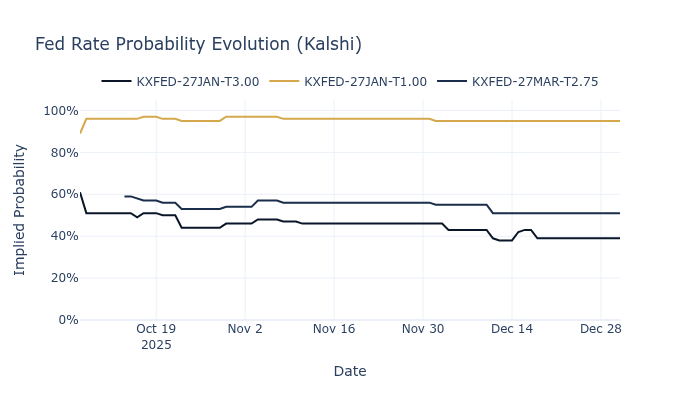

In [7]:
# Volume is near zero across these contracts, so "most active" means the widest range
# in implied probability (on the cleaned data), which flags the genuine battleground
# thresholds rather than a data glitch.
price_range = (
    df.group_by("symbol")
    .agg((pl.col("close").max() - pl.col("close").min()).alias("range"))
    .sort("range", descending=True)
)

top_contracts = price_range.head(3)["symbol"].to_list()

fig = go.Figure()
palette = [COLORS["blue"], COLORS["amber"], COLORS["slate"]]

for sym, color in zip(top_contracts, palette, strict=False):
    data = df.filter(pl.col("symbol") == sym).sort("timestamp").to_pandas()
    fig.add_trace(
        go.Scatter(
            x=data["timestamp"],
            y=data["close"],
            mode="lines",
            name=sym,
            line=dict(color=color, width=2),
        )
    )

fig.update_layout(
    title="Fed Rate Probability Evolution (Kalshi)",
    xaxis_title="Date",
    yaxis_title="Implied Probability",
    yaxis=dict(tickformat=".0%", range=[0, 1.05]),
    template="plotly_white",
    height=400,
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="center", x=0.5),
)

fig.show()

The contracts with rate thresholds near the current rate show the most
price movement — these are the "battleground" levels where the market
is genuinely uncertain. Contracts far from the current rate trade near
0 or 1 with little movement.

## 5. Multi-Threshold View

Looking at all thresholds for a single meeting gives a snapshot of the
market's full probability distribution over rate outcomes.

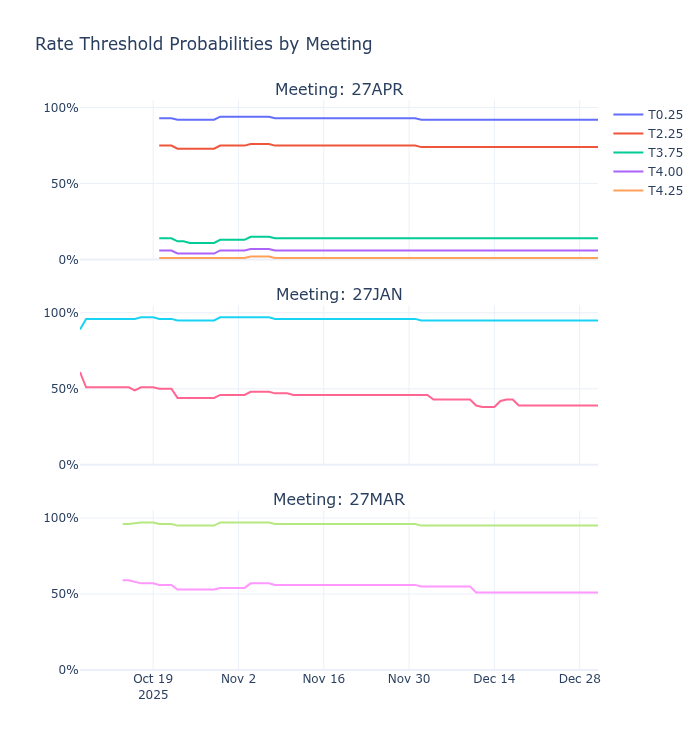

In [8]:
# Group by meeting date prefix
meetings = {}
for sym in df["symbol"].unique().to_list():
    # KXFED-27APR-T4.25 → 27APR
    parts = sym.split("-")
    if len(parts) >= 3:
        meeting = parts[1]
        meetings.setdefault(meeting, []).append(sym)

fig = make_subplots(
    rows=len(meetings),
    cols=1,
    shared_xaxes=True,
    subplot_titles=[f"Meeting: {m}" for m in sorted(meetings.keys())],
    vertical_spacing=0.08,
)

for i, (meeting, symbols) in enumerate(sorted(meetings.items()), 1):
    for sym in sorted(symbols):
        data = df.filter(pl.col("symbol") == sym).sort("timestamp").to_pandas()
        threshold = sym.split("-T")[-1] if "-T" in sym else sym
        fig.add_trace(
            go.Scatter(
                x=data["timestamp"],
                y=data["close"],
                mode="lines",
                name=f"T{threshold}",
                showlegend=(i == 1),
            ),
            row=i,
            col=1,
        )
    fig.update_yaxes(tickformat=".0%", range=[0, 1.05], row=i, col=1)

fig.update_layout(
    height=250 * len(meetings),
    title_text="Rate Threshold Probabilities by Meeting",
    template="plotly_white",
)

fig.show()

## 6. Day-over-Day Probability Dynamics

These markets trade on only a handful of days in the sample; the rest are zero-volume
carry-forward snapshots with no genuine intraday range. Intraday high/low is therefore
not a meaningful signal here. What moves is the day-over-day implied probability (the
`close` path), so we summarize each contract by how many days it actually traded and by
the volatility of its daily probability changes. Contracts whose threshold sits near the
expected rate show the largest daily moves.

In [9]:
df_enriched = df.sort("symbol", "timestamp").with_columns(
    pl.col("close").diff().over("symbol").alias("prob_change"),
)

activity = (
    df_enriched.group_by("symbol")
    .agg(
        (pl.col("volume") > 0).sum().alias("traded_days"),
        pl.col("volume").sum().round(1).alias("total_volume"),
        pl.col("prob_change").std().round(4).alias("daily_prob_vol"),
        pl.col("prob_change").abs().max().round(4).alias("max_daily_move"),
    )
    .sort("daily_prob_vol", descending=True, nulls_last=True)
)

activity

symbol,traded_days,total_volume,daily_prob_vol,max_daily_move
str,u32,f64,f64,f64
"""KXFED-27JAN-T3.00""",3,312.0,0.0157,0.1
"""KXFED-27JAN-T1.00""",0,0.0,0.0083,0.07
"""KXFED-27MAR-T2.75""",0,0.0,0.0074,0.04
"""KXFED-27APR-T3.75""",1,2.0,0.0044,0.02
"""KXFED-27APR-T2.25""",0,0.0,0.0039,0.02
"""KXFED-27APR-T4.00""",0,0.0,0.0038,0.02
"""KXFED-27MAR-T0.50""",1,1.0,0.0034,0.02
"""KXFED-27APR-T0.25""",0,0.0,0.0031,0.02
"""KXFED-27APR-T4.25""",0,0.0,0.0018,0.01


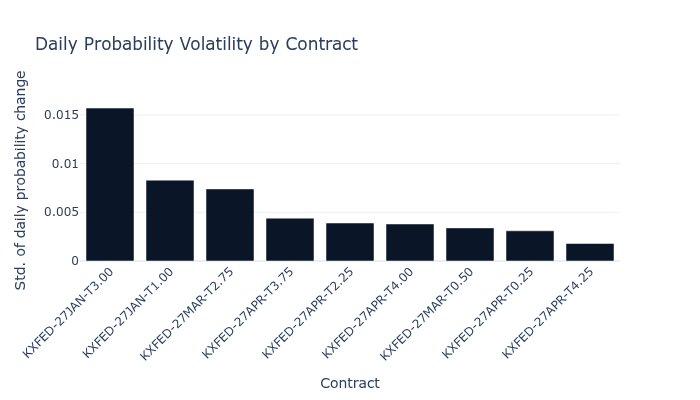

In [10]:
ad = activity.to_pandas()
fig = go.Figure(go.Bar(x=ad["symbol"], y=ad["daily_prob_vol"], marker_color=COLORS["blue"]))
fig.update_layout(
    title="Daily Probability Volatility by Contract",
    xaxis_title="Contract",
    yaxis_title="Std. of daily probability change",
    template="plotly_white",
    height=400,
)
fig.update_xaxes(tickangle=-45)
fig.show()

## 7. Event Indicators for ML

Transform Kalshi probabilities into ML-ready features. Since `close`
is already the implied probability, we derive momentum, volatility,
and regime indicators directly.

In [11]:
LOOKBACK = 5
VOL_WINDOW = 10

kalshi_features = df.sort("symbol", "timestamp").with_columns(
    (pl.col("close") - pl.col("close").shift(LOOKBACK).over("symbol")).alias("prob_momentum"),
    pl.col("close").diff().rolling_std(VOL_WINDOW).over("symbol").alias("prob_volatility"),
    pl.when(pl.col("close").rolling_std(VOL_WINDOW).over("symbol") > 0)
    .then(
        (pl.col("close") - pl.col("close").rolling_mean(VOL_WINDOW).over("symbol"))
        / pl.col("close").rolling_std(VOL_WINDOW).over("symbol")
    )
    .otherwise(0.0)
    .alias("prob_zscore"),
    ((pl.col("close") > 0.8) | (pl.col("close") < 0.2)).cast(pl.Int8).alias("high_confidence"),
    (pl.col("high") - pl.col("low")).alias("uncertainty"),
)

print(f"Feature matrix: {kalshi_features.shape}")
kalshi_features.select(
    "timestamp", "symbol", "close", "prob_momentum", "prob_volatility", "high_confidence"
).head(10)

Feature matrix: (687, 13)


timestamp,symbol,close,prob_momentum,prob_volatility,high_confidence
date,str,f64,f64,f64,i8
2025-10-20,"""KXFED-27APR-T0.25""",0.93,null,null,1
2025-10-21,"""KXFED-27APR-T0.25""",0.93,null,null,1
2025-10-22,"""KXFED-27APR-T0.25""",0.93,null,null,1
2025-10-23,"""KXFED-27APR-T0.25""",0.92,null,null,1
2025-10-24,"""KXFED-27APR-T0.25""",0.92,null,null,1
2025-10-25,"""KXFED-27APR-T0.25""",0.92,-0.01,null,1
2025-10-26,"""KXFED-27APR-T0.25""",0.92,-0.01,null,1
2025-10-27,"""KXFED-27APR-T0.25""",0.92,-0.01,null,1
2025-10-28,"""KXFED-27APR-T0.25""",0.92,0.0,null,1


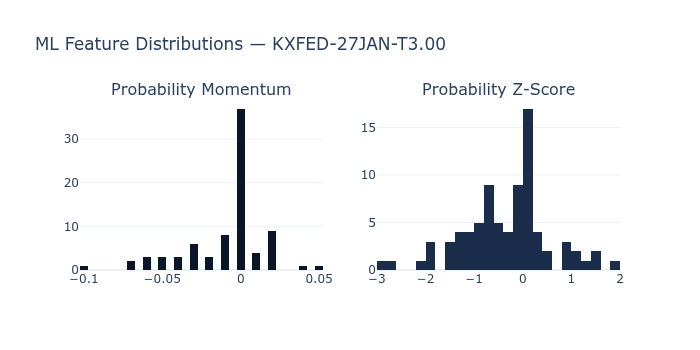

In [12]:
# Feature distributions for the most active contract
active_sym = top_contracts[0]
active_features = kalshi_features.filter(
    (pl.col("symbol") == active_sym) & pl.col("prob_momentum").is_not_null()
)

fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=("Probability Momentum", "Probability Z-Score"),
)

fig.add_trace(
    go.Histogram(
        x=active_features["prob_momentum"].to_list(),
        nbinsx=30,
        name="Momentum",
        marker_color=COLORS["blue"],
    ),
    row=1,
    col=1,
)

fig.add_trace(
    go.Histogram(
        x=active_features["prob_zscore"].to_list(),
        nbinsx=30,
        name="Z-Score",
        marker_color=COLORS["slate"],
    ),
    row=1,
    col=2,
)

fig.update_layout(
    title=f"ML Feature Distributions — {active_sym}",
    height=350,
    showlegend=False,
    template="plotly_white",
)

fig.show()

## 8. Data Quality Assessment

Two checks matter for prediction-market data: whether any bars were corrupt (caught
and repaired at load), and how much genuine price variation each contract carries.

In [13]:
print(f"Zero-price artifact bars caught and repaired at load: {artifact_bars.height}")
artifact_bars

Zero-price artifact bars caught and repaired at load: 35


timestamp,symbol,open,high,low,close,volume
date,str,f64,f64,f64,f64,f64
2025-10-08,"""KXFED-27JAN-T1.00""",0.89,0.96,0.0,0.96,0.0
2025-10-08,"""KXFED-27JAN-T3.00""",0.61,0.61,0.0,0.51,0.0
2025-10-15,"""KXFED-27JAN-T1.00""",0.96,0.96,0.0,0.0,0.0
2025-10-15,"""KXFED-27JAN-T3.00""",0.51,0.51,0.0,0.0,0.0
2025-10-15,"""KXFED-27MAR-T0.50""",0.96,0.96,0.0,0.0,0.0
…,…,…,…,…,…,…
2025-12-02,"""KXFED-27APR-T4.25""",0.01,0.01,0.0,0.01,0.0
2025-12-11,"""KXFED-27APR-T4.00""",0.06,0.06,0.0,0.06,0.0
2025-12-11,"""KXFED-27APR-T4.25""",0.01,0.01,0.0,0.01,0.0


In [14]:
quality_df = (
    df.group_by("symbol")
    .agg(
        pl.len().alias("observations"),
        pl.col("volume").mean().round(3).alias("avg_volume"),
        (pl.col("close").max() - pl.col("close").min()).round(3).alias("price_range"),
    )
    .sort("price_range", descending=True)
)
quality_df

symbol,observations,avg_volume,price_range
str,u32,f64,f64
"""KXFED-27JAN-T3.00""",86,3.628,0.23
"""KXFED-27JAN-T1.00""",86,0.0,0.08
"""KXFED-27MAR-T2.75""",78,0.0,0.08
"""KXFED-27APR-T3.75""",73,0.027,0.04
"""KXFED-27APR-T2.25""",73,0.0,0.03
"""KXFED-27APR-T4.00""",73,0.0,0.03
"""KXFED-27APR-T0.25""",73,0.0,0.02
"""KXFED-27MAR-T0.50""",78,0.013,0.02
"""KXFED-27APR-T4.25""",67,0.0,0.01


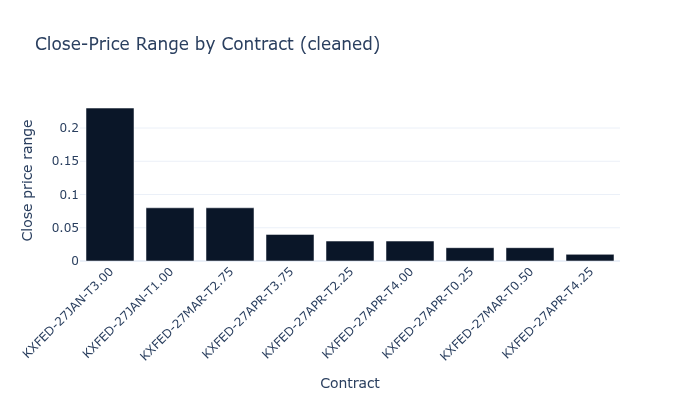

In [15]:
qd = quality_df.to_pandas()
fig = go.Figure(go.Bar(x=qd["symbol"], y=qd["price_range"], marker_color=COLORS["blue"]))
fig.update_layout(
    title="Close-Price Range by Contract (cleaned)",
    xaxis_title="Contract",
    yaxis_title="Close price range",
    template="plotly_white",
    height=400,
)
fig.update_xaxes(tickangle=-45)
fig.show()

After repairing the corrupt bars, price variation reflects real market movement.
Volume is near zero across the universe, so the range in implied probability, not
turnover, is the useful activity signal: contracts whose thresholds sit near the
expected rate move the most and carry the richest information for ML features.

## 9. Save Enriched Data

In [16]:
output_dir = get_output_dir(4, "kalshi")
output_dir.mkdir(parents=True, exist_ok=True)

output_file = output_dir / "kalshi_features.parquet"
kalshi_features.write_parquet(output_file)

print(f"Saved {len(kalshi_features)} observations to {output_file}")

Saved 687 observations to /home/stefan/ml4t/code/04_fundamental_alternative_data/output/kalshi/kalshi_features.parquet


## Key Takeaways

1. **Implied probability = close price**: Kalshi contract prices directly encode
   the market's probability estimate for the event, no transformation needed

2. **Threshold structure**: Multiple contracts per meeting create a full
   probability distribution over rate outcomes — richer than a single forecast

3. **Feature engineering**: Momentum, volatility, and z-score of probability
   paths provide regime-detection signals for rate-sensitive strategies

4. **Liquidity caveat**: Economic event contracts are still early-stage;
   volume is thin compared to traditional derivatives markets

5. **Screen for corrupt bars first**: thin, carry-forward markets are prone to
   ingestion artifacts (a positive high with a zero close). Detect and repair them
   before ranking or feature engineering, or a single bad bar distorts both.

**Next**: See [`13_polymarket_prediction_markets`](13_polymarket_prediction_markets.ipynb) for the higher-liquidity
crypto-based alternative and cross-platform comparison.